# 05 — Normalização: a fraude piorou, ou o Pix cresceu?

**Objetivo:** as etapas 4 a 6 mostraram que as contestações triplicaram em
out/2025. Mas o Pix também cresceu muito no período. Número absoluto engana
quando a base cresce: sem dividir pelo total de transações, não dá pra dizer
se a fraude piorou.

Faz parte da [etapa 7](../README.md#progresso) do projeto — a mais
importante dele.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import os
import sys
import urllib.request

sys.path.insert(0, "..")
if not os.path.exists("../visual.py"):  # fora do repositorio (ex: Colab): baixa o padrao visual
    urllib.request.urlretrieve("https://raw.githubusercontent.com/ivadivad/med-em-numeros/main/visual.py", "visual.py")
from visual import grafico, salvar, AZUL, LARANJA, CINZA, TEXTO_SECUNDARIO, FONTE_FRAUDE_E_TRANSACOES

RAW = "https://raw.githubusercontent.com/ivadivad/med-em-numeros/main/dados"
fraude = pd.read_csv(f"{RAW}/fraude.csv")
transacoes = pd.read_csv(f"{RAW}/transacoes.csv")
fraude.shape, transacoes.shape

((52, 24), (71, 4))

## A tabela de transações

`dados/transacoes.csv` já chega com **uma linha por mês**: o `groupby` por
`AnoMes` que o plano previa fazer aqui foi feito no coletor. A tabela crua tem
de 1,8 mil a 17 mil linhas por mês (uma por combinação de PF/PJ, região,
idade, forma de iniciação, natureza e finalidade) e centenas de MB no total —
não cabe no repositório. `LinhasOrigem` registra quantas linhas cruas entraram
em cada total.

In [2]:
transacoes["Data"] = pd.to_datetime(transacoes["AnoMes"], format="%Y%m")
transacoes = transacoes.sort_values("Data").reset_index(drop=True)
print(f"de {transacoes['Data'].min():%Y-%m} a {transacoes['Data'].max():%Y-%m}, {len(transacoes)} meses")
transacoes.tail(3)

de 2020-11 a 2026-09, 71 meses


,AnoMes,VALOR,QUANTIDADE,LinhasOrigem,Data
68,202607,3.223293e+12,7238374542,13433,2026-07-01
69,202608,3.174483e+12,7366981446,13374,2026-08-01
70,202609,3.225144e+12,7169724394,13350,2026-09-01


### Validando o denominador contra um número publicado

Antes de dividir qualquer coisa por esta tabela, ela precisa bater com uma
fonte externa — mesmo procedimento da etapa 3. O Banco Central divulgou, para
2025, **R$ 35,3 trilhões** movimentados, **~80 bilhões** de transações e
crescimento de **33,7%** sobre 2024
([Let's Money, 15/01/2026, citando o BC](https://www.letsmoney.com.br/pix/pix-bate-recorde-trilhoes-2025/)).

In [3]:
transacoes["ano"] = transacoes["AnoMes"] // 100
por_ano = transacoes.groupby("ano")[["VALOR", "QUANTIDADE"]].sum()

valor_2025 = por_ano.loc[2025, "VALOR"] / 1e12
qtd_2025 = por_ano.loc[2025, "QUANTIDADE"] / 1e9
crescimento = (por_ano.loc[2025, "VALOR"] / por_ano.loc[2024, "VALOR"] - 1) * 100

print(f"valor 2025:       R$ {valor_2025:.1f} tri   (publicado: R$ 35,3 tri -> {valor_2025 / 35.3:.0%})")
print(f"transacoes 2025:  {qtd_2025:.1f} bi       (publicado: ~80 bi      -> {qtd_2025 / 80:.0%})")
print(f"crescimento 2025: {crescimento:.1f}%      (publicado: 33,7%)")

valor 2025:       R$ 29.6 tri   (publicado: R$ 35,3 tri -> 84%)
transacoes 2025:  71.3 bi       (publicado: ~80 bi      -> 89%)
crescimento 2025: 33.8%      (publicado: 33,7%)


**O crescimento bate quase exato; o nível fica abaixo.** A explicação está na
descrição oficial da tabela, no
[portal de dados abertos do BC](https://dadosabertos.bcb.gov.br/dataset/pix/resource/d5430811-0ef7-4404-bc87-d76aa5cfebcd):

> "Quantidade e volume financeiro de transações Pix liquidadas mensalmente.
> Não inclui Pix liquidados nos livros do participante, isto é, transações não
> enviadas para liquidação no SPI."

Ou seja: ficam de fora as transferências entre contas da mesma instituição. É
diferença de **escopo**, não dado perdido na coleta — se a API tivesse cortado
respostas, a perda variaria de mês a mês e o crescimento não bateria em 0,1
ponto.

**Consequência pra esta etapa:** as taxas "por milhão de transações" abaixo
ficam um pouco acima do que seriam sobre o Pix inteiro (o denominador é ~11%
menor). As **tendências** não são afetadas, desde que essa fatia seja estável —
e o crescimento igual ao publicado indica que é.

## Juntando fraude e volume

`merge` pelo `AnoMes`. A tabela de fraude vai até abr/2026 (defasagem maior
que a de transações, que vai até set/2026); cada mês da fraude precisa achar
seu par.

In [4]:
df = fraude.merge(transacoes, on="AnoMes", how="left", validate="one_to_one", indicator=True)
df["Data"] = pd.to_datetime(df["AnoMes"], format="%Y%m")
df = df.sort_values("Data").reset_index(drop=True)

sem_par = (df["_merge"] != "both").sum()
print(f"linhas da fraude: {len(fraude)}  |  depois do merge: {len(df)}  |  sem par em transacoes: {sem_par}")

linhas da fraude: 52  |  depois do merge: 52  |  sem par em transacoes: 0


Nenhuma linha perdida nem duplicada (`validate="one_to_one"` falharia se
houvesse mês repetido em qualquer lado).

### Uma segunda validação, mais forte

A tabela de fraude tem uma coluna, `Qtdecontestacoesaceitasacada100mil`, cujo
denominador a documentação não declara. Se ele for o total de transações do
mês, dá pra recalculá-la com a tabela coletada aqui:

In [5]:
recalculada = df["Qtdecontestacoesaceitas"] / df["QUANTIDADE"] * 100_000
erro = (df["Qtdecontestacoesaceitasacada100mil"] - recalculada).abs()
print(f"erro maximo: {erro.max():.4f} em {len(df)} meses")

erro maximo: 0.0005 em 52 meses


**Bate, com erro máximo de 0,0005 — arredondamento.** O próprio Banco Central calcula essa coluna com o mesmo
denominador coletado nesta etapa — o que confirma, ao mesmo tempo, o que a
coluna significa e que a coleta de transações não perdeu linha (se tivesse
perdido, a conta não fecharia em nenhum mês).

## Fraude como proporção do volume

Duas medidas, porque a base tem duas definições de "fraude" — e elas contam
histórias opostas:

- **pedidos de contestação** por milhão de transações: o que as vítimas
  alegam;
- **contestações aceitas** por milhão de transações: o que a instituição
  reconhece como fraude.

In [6]:
df["contestacoes_por_milhao"] = df["QtdePixcontestados"] / df["QUANTIDADE"] * 1e6
df["aceitas_por_milhao"] = df["Qtdecontestacoesaceitas"] / df["QUANTIDADE"] * 1e6
df["valor_aceito_por_mil_reais"] = df["ValorPixcontestadosaceitos"] / df["VALOR"] * 1000

df["ano"] = df["AnoMes"] // 100
df.groupby("ano")[["contestacoes_por_milhao", "aceitas_por_milhao", "valor_aceito_por_mil_reais"]].mean().round(2)

,contestacoes_por_milhao,aceitas_por_milhao,valor_aceito_por_mil_reais
ano,,,
2022,103.30,75.46,0.31
2023,122.80,71.24,0.30
2024,215.78,86.97,0.30
2025,302.97,55.95,0.26
2026,461.71,44.76,0.24


## A série normalizada

O mesmo recorte do gráfico da etapa 5 (contestados e aceitas), agora dividido
pelo número de transações do mês.

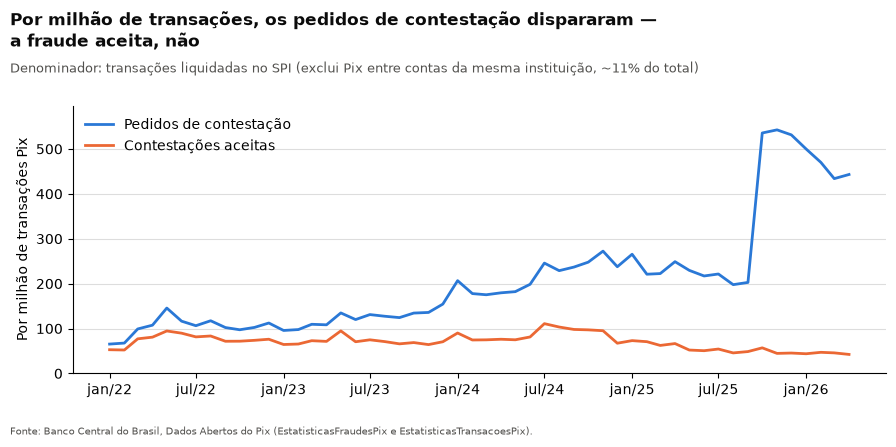

In [7]:
fig, ax = grafico(
    "Por milhão de transações, os pedidos de contestação dispararam —\na fraude aceita, não",
    subtitulo="Denominador: transações liquidadas no SPI (exclui Pix entre contas da mesma instituição, ~11% do total)",
    fonte=FONTE_FRAUDE_E_TRANSACOES,
)
ax.plot(df["Data"], df["contestacoes_por_milhao"], color=AZUL, linewidth=2, label="Pedidos de contestação")
ax.plot(df["Data"], df["aceitas_por_milhao"], color=LARANJA, linewidth=2, label="Contestações aceitas")
ax.set_ylim(0, df["contestacoes_por_milhao"].max() * 1.1)
ax.set_ylabel("Por milhão de transações Pix")
ax.legend(frameon=False, loc="upper left")

salvar(fig, "05-fraude-normalizada.png")
plt.show()

## Absoluto contra normalizado

Três séries com escalas sem nenhuma relação entre si (bilhões de transações,
milhões de pedidos, centenas de milhares de aceitas) só cabem no mesmo eixo
se forem **indexadas a uma base comum**: média de 2022 = 100. Nada de dois
eixos Y.

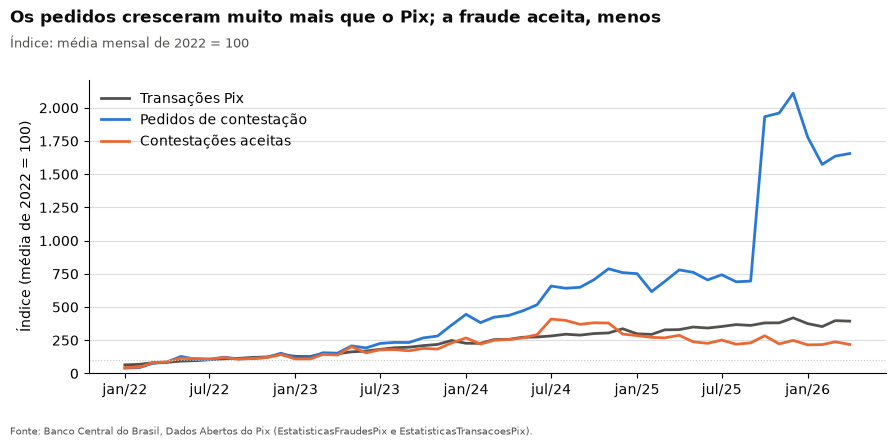

In [8]:
base_2022 = df[df["ano"] == 2022]
series = {
    "Transações Pix": ("QUANTIDADE", TEXTO_SECUNDARIO),
    "Pedidos de contestação": ("QtdePixcontestados", AZUL),
    "Contestações aceitas": ("Qtdecontestacoesaceitas", LARANJA),
}

fig, ax = grafico(
    "Os pedidos cresceram muito mais que o Pix; a fraude aceita, menos",
    subtitulo="Índice: média mensal de 2022 = 100",
    fonte=FONTE_FRAUDE_E_TRANSACOES,
)
for rotulo, (coluna, cor) in series.items():
    indice = df[coluna] / base_2022[coluna].mean() * 100
    ax.plot(df["Data"], indice, color=cor, linewidth=2, label=rotulo)

ax.axhline(100, color=CINZA, linewidth=0.8, linestyle=":")
ax.set_ylim(0, None)
ax.set_ylabel("Índice (média de 2022 = 100)")
ax.legend(frameon=False, loc="upper left")

salvar(fig, "05-absoluto-vs-normalizado.png")
plt.show()

In [9]:
media = df.groupby("ano")[["QUANTIDADE", "QtdePixcontestados", "Qtdecontestacoesaceitas"]].mean()
multiplicador = (media.loc[2025] / media.loc[2022]).round(1)
multiplicador.rename({"QUANTIDADE": "Transações Pix", "QtdePixcontestados": "Pedidos de contestação",
                      "Qtdecontestacoesaceitas": "Contestações aceitas"}).to_frame("2025 / 2022 (médias mensais)")

,2025 / 2022 (médias mensais)
Transações Pix,3.5
Pedidos de contestação,10.4
Contestações aceitas,2.5


In [10]:
antes, depois = df[df["AnoMes"] == 202509].iloc[0], df[df["AnoMes"] == 202510].iloc[0]
print(f"set/2025 -> out/2025: transacoes {depois['QUANTIDADE'] / antes['QUANTIDADE'] - 1:+.0%}, "
      f"pedidos de contestacao {depois['QtdePixcontestados'] / antes['QtdePixcontestados'] - 1:+.0%}")

set/2025 -> out/2025: transacoes +5%, pedidos de contestacao +178%


## Qual conta a verdade

**O número absoluto conta uma história errada.** Os pedidos de contestação
cresceram ~10× entre 2022 e 2025 — mas o Pix cresceu 3,5× no mesmo período.
Quem lê só o absoluto superestima o crescimento em quase três vezes.

**Normalizado, as duas medidas de fraude apontam para lados opostos:**

- **Pedidos por milhão de transações subiram de verdade:** de ~103 (média de
  2022) para ~303 (2025) e ~462 (jan–abr/2026). E o salto de out/2025 **não é
  efeito do crescimento do Pix**: naquele mês as transações cresceram 5%, os
  pedidos 178%. Isso reforça a leitura da etapa 6 — a mudança foi no jeito de
  contestar (botão 100% digital), não no tamanho do Pix.
- **Fraude aceita por milhão de transações caiu — mas só a partir de 2025.**
  Não foi uma queda contínua: de 2022 a jun/2024 ela andou junto com o Pix
  (média ~74 por milhão — no gráfico indexado, a linha laranja fica em cima da
  cinza), teve um pico no 2º semestre de 2024 (média ~95) e só então caiu:
  ~56 em 2025, ~45 em jan–abr/2026. Em valor, a mesma direção: R$ 0,31 de
  fraude aceita a cada R$ 1.000 transacionados em 2022, R$ 0,26 em 2025,
  R$ 0,24 em 2026. Por que houve o pico de 2024 e a queda depois, esta base
  não diz.

**Então a fraude piorou?** Depende do que se chama de fraude, e a base não
deixa escolher com segurança:

- Medida pelo que **as vítimas relatam**, piorou — e muito.
- Medida pelo que **a instituição reconhece**, melhorou.
- Mas quem decide se aceita é a própria instituição contestada (limitação
  registrada no README). A queda da fraude aceita por transação pode ser menos
  fraude **ou** instituições mais rígidas no crivo — a taxa de aceite já vinha
  caindo desde 2022 (etapa 5). Esta base não separa as duas coisas.
- E os pedidos já vinham se descolando do Pix antes de out/2025: no gráfico
  indexado, a linha azul se separa da cinza a partir do fim de 2023. O botão
  digital acelerou uma divergência que já existia — o mesmo padrão que a etapa
  5 achou na taxa de aceite.

O que dá pra afirmar sem ressalva: **o crescimento absoluto das contestações
não é evidência de que a fraude piorou.** Uma parte grande é o Pix crescendo;
outra é a contestação ter ficado mais fácil; e a fração reconhecida como
fraude, por transação, diminuiu.

**Ressalvas desta etapa:**

- O denominador exclui Pix entre contas da mesma instituição (~11% das
  transações). Os níveis por milhão ficam um pouco acima do real; as
  tendências, não.
- 2026 tem só 4 meses.
- Fraude não contestada não aparece em nenhuma das duas medidas.